In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
ratings.shape

(100000, 4)

In [4]:
movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["item_id", "movie_title"]
)

movies.head()

,item_id,movie_title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [5]:
ratings.merge(
    movies,
    on="item_id"
).head(10)

,user_id,item_id,rating,timestamp,movie_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)
5,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...
6,115,265,2,881171488,"Hunt for Red October, The (1990)"
7,253,465,5,891628467,"Jungle Book, The (1994)"
8,305,451,3,886324817,Grease (1978)
9,6,86,3,883603013,"Remains of the Day, The (1993)"


In [6]:
ratings_with_movies = ratings.merge(
    movies,
    on="item_id",
    how="left"
)

ratings_with_movies.head(10)

,user_id,item_id,rating,timestamp,movie_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)
5,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...
6,115,265,2,881171488,"Hunt for Red October, The (1990)"
7,253,465,5,891628467,"Jungle Book, The (1994)"
8,305,451,3,886324817,Grease (1978)
9,6,86,3,883603013,"Remains of the Day, The (1993)"


In [8]:
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating"
)

In [9]:
user_item_matrix.head()

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("Matrix shape:", user_item_matrix.shape)

Matrix shape: (943, 1682)


In [11]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [12]:
user_item_matrix_filled.head()

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
user_similarity = cosine_similarity(
    user_item_matrix_filled
)

In [14]:
print(user_similarity.shape)

(943, 943)


In [15]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

In [16]:
user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


In [17]:
user_id = 1

similar_users = user_similarity_df.loc[user_id].sort_values(
    ascending=False
)

similar_users.head(10)

user_id
1      1.000000
916    0.569066
864    0.547548
268    0.542077
92     0.540534
435    0.538665
457    0.538476
738    0.527031
429    0.525950
303    0.525718
Name: 1, dtype: float64

In [18]:
similar_users = similar_users.drop(user_id)

In [19]:
similar_users.head(10)

user_id
916    0.569066
864    0.547548
268    0.542077
92     0.540534
435    0.538665
457    0.538476
738    0.527031
429    0.525950
303    0.525718
276    0.524523
Name: 1, dtype: float64

In [20]:
user_ratings = user_item_matrix.loc[user_id]

user_ratings = user_ratings[
    user_ratings.notna()
]

user_ratings.head(10)

item_id
1     5.0
2     3.0
3     4.0
4     3.0
5     3.0
6     5.0
7     4.0
8     1.0
9     5.0
10    3.0
Name: 1, dtype: float64

In [21]:
user_movies = ratings_with_movies[
    ratings_with_movies["user_id"] == user_id
]

user_movies[
    ["item_id", "movie_title", "rating"]
].sort_values(
    "rating",
    ascending=False
).head(10)

,item_id,movie_title,rating
82786,204,Back to the Future (1985),5
78817,216,When Harry Met Sally... (1989),5
75385,198,Nikita (La Femme Nikita) (1990),5
3888,60,Three Colors: Blue (1993),5
77073,124,Lone Star (1996),5
3431,221,Breaking the Waves (1996),5
74577,165,Jean de Florette (1986),5
2328,64,"Shawshank Redemption, The (1994)",5
3234,114,Wallace & Gromit: The Best of Aardman Animatio...,5
3059,228,Star Trek: The Wrath of Khan (1982),5


In [22]:
def recommend_movies(
    user_id,
    n_recommendations=5,
    n_similar_users=10
):
    
    # Find similar users
    similar_users = user_similarity_df.loc[user_id].sort_values(
        ascending=False
    )
    
    # Remove the target user
    similar_users = similar_users.drop(user_id)
    
    # Take top similar users
    similar_users = similar_users.head(n_similar_users)
    
    # Movies already rated by target user
    user_ratings = user_item_matrix.loc[user_id]
    
    watched_movies = set(
        user_ratings[user_ratings.notna()].index
    )
    
    # Recommendation scores
    recommendation_scores = {}
    
    # Go through similar users
    for similar_user_id, similarity_score in similar_users.items():
        
        similar_user_ratings = user_item_matrix.loc[
            similar_user_id
        ]
        
        # Movies rated by similar user
        rated_movies = similar_user_ratings[
            similar_user_ratings.notna()
        ]
        
        for movie_id, rating in rated_movies.items():
            
            # Skip movies already watched
            if movie_id in watched_movies:
                continue
            
            # Weighted score
            score = similarity_score * rating
            
            if movie_id not in recommendation_scores:
                recommendation_scores[movie_id] = 0
            
            recommendation_scores[movie_id] += score
    
    # Sort recommendations
    recommendations = sorted(
        recommendation_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )
    
    # Top N
    recommendations = recommendations[:n_recommendations]
    
    # Convert to DataFrame
    recommendations_df = pd.DataFrame(
        recommendations,
        columns=[
            "item_id",
            "recommendation_score"
        ]
    )
    
    # Add movie names
    recommendations_df = recommendations_df.merge(
        movies,
        on="item_id",
        how="left"
    )
    
    return recommendations_df[
        [
            "item_id",
            "movie_title",
            "recommendation_score"
        ]
    ]

In [23]:
recommend_movies(
    user_id=1,
    n_recommendations=5
)

,item_id,movie_title,recommendation_score
0,318,Schindler's List (1993),21.996880
1,474,Dr. Strangelove or: How I Learned to Stop Worr...,21.006675
2,655,Stand by Me (1986),19.883163
3,423,E.T. the Extra-Terrestrial (1982),19.857810
4,403,Batman (1989),19.788317


In [24]:
recommend_movies(
    user_id=50,
    n_recommendations=5
)

,item_id,movie_title,recommendation_score
0,50,Star Wars (1977),11.557638
1,129,Bound (1996),9.830353
2,293,Donnie Brasco (1997),9.605136
3,127,"Godfather, The (1972)",9.119297
4,93,Welcome to the Dollhouse (1995),8.624411


In [25]:
recommend_movies(
    user_id=100,
    n_recommendations=5
)

,item_id,movie_title,recommendation_score
0,327,Cop Land (1997),18.374302
1,307,"Devil's Advocate, The (1997)",15.649121
2,303,Ulee's Gold (1997),15.225693
3,331,"Edge, The (1997)",13.914365
4,322,Murder at 1600 (1997),13.572355


In [26]:
ratings["user_id"].unique()

array([196, 186,  22, 244, 166, 298, 115, 253, 305,   6,  62, 286, 200,
       210, 224, 303, 122, 194, 291, 234, 119, 167, 299, 308,  95,  38,
       102,  63, 160,  50, 301, 225, 290,  97, 157, 181, 278, 276,   7,
        10, 284, 201, 287, 246, 242, 249,  99, 178, 251,  81, 260,  25,
        59,  72,  87,  42, 292,  20,  13, 138,  60,  57, 223, 189, 243,
        92, 241, 254, 293, 127, 222, 267,  11,   8, 162, 279, 145,  28,
       135,  32,  90, 216, 250, 271, 265, 198, 168, 110,  58, 237,  94,
       128,  44, 264,  41,  82, 262, 174,  43,  84, 269, 259,  85, 213,
       121,  49, 155,  68, 172,  19, 268,   5,  80,  66,  18,  26, 130,
       256,   1,  56,  15, 207, 232,  52, 161, 148, 125,  83, 272, 151,
        54,  16,  91, 294, 229,  36,  70,  14, 295, 233, 214, 192, 100,
       307, 297, 193, 113, 275, 219, 218, 123, 158, 302,  23, 296,  33,
       154,  77, 270, 187, 170, 101, 184, 112, 133, 215,  69, 104, 240,
       144, 191,  61, 142, 177, 203,  21, 197, 134, 180, 236, 26

In [27]:
user_id = 1

top_5_recommendations = recommend_movies(
    user_id=user_id,
    n_recommendations=5
)

print(f"Top 5 Movie Recommendations for User {user_id}")

top_5_recommendations

Top 5 Movie Recommendations for User 1


,item_id,movie_title,recommendation_score
0,318,Schindler's List (1993),21.996880
1,474,Dr. Strangelove or: How I Learned to Stop Worr...,21.006675
2,655,Stand by Me (1986),19.883163
3,423,E.T. the Extra-Terrestrial (1982),19.857810
4,403,Batman (1989),19.788317


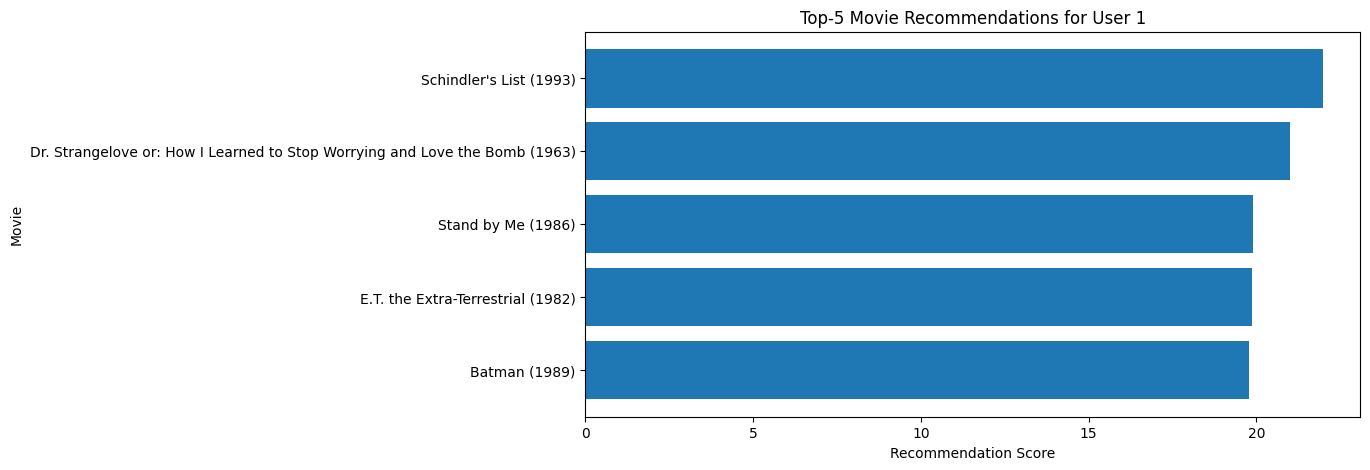

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.barh(
    top_5_recommendations["movie_title"],
    top_5_recommendations["recommendation_score"]
)

plt.xlabel("Recommendation Score")
plt.ylabel("Movie")
plt.title(
    f"Top-5 Movie Recommendations for User {user_id}"
)

plt.gca().invert_yaxis()

plt.show()